## Import Library

- `NumPy` untuk mengelola, memanipulasi, dan melakukan operasi matematis pada array atau matriks citra

- `Matplotlib`  untuk menampilkan citra, histogram, serta visualisasi hasil pengolahan gambar

- `OpenCV` untuk membaca gambar, melakukan konversi warna, dan membantu berbagai proses pengolahan citra digital

In [235]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2 as cv

## Function Pengolahan dan Menampilkan Citra

Function `pastikan_uint8()` untuk memastikan citra memiliki format `uint8` dengan rentang nilai piksel 0–255. Jika citra masih berupa float dengan rentang 0–1 maka nilai piksel akan dikalikan 255 terlebih dahulu sebelum dikonversi

Function `bacaAbu()` untuk membaca gambar grayscale menggunakan OpenCV. Selain membaca gambar, function ini juga untuk mengecek apakah file gambar tersedia atau tidak

Function `bacaRGB()` untuk membaca gambar berwarna. Karena OpenCV membaca gambar dalam format BGR, maka dilakukan konversi menjadi RGB agar warna sesuai saat ditampilkan menggunakan Matplotlib

Function `tampilkan()` untuk menampilkan satu citra. Function ini dapat menampilkan citra grayscale maupun RGB serta memberikan judul pada gambar

Function `tampilkan_beberapa()` untuk menampilkan beberapa citra sekaligus dalam satu figure

In [236]:
def pastikan_uint8(citra):
    citra = np.array(citra)
    if citra.dtype == np.uint8:
        return citra
    if citra.max() <= 1.0:
        citra = citra * 255

    return np.clip(citra, 0, 255).astype(np.uint8)


def bacaAbu(path):
    citra = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if citra is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    return pastikan_uint8(citra)


def bacaRGB(path):
    citra_bgr = cv.imread(path, cv.IMREAD_COLOR)
    if citra_bgr is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")
    citra_rgb = cv.cvtColor(citra_bgr, cv.COLOR_BGR2RGB)

    return pastikan_uint8(citra_rgb)


def tampilkan(citra, judul="Citra", cmap="gray", figsize=(8, 5)):
    plt.figure(figsize=figsize)
    if len(citra.shape) == 2:
        plt.imshow(citra, cmap=cmap)
    else:
        plt.imshow(citra)
    plt.title(judul)
    plt.show()

def tampilkan_beberapa(daftar_citra, daftar_judul=None, cmap="gray", figsize=(14, 5)):
    jumlah = len(daftar_citra)
    if daftar_judul is None:
        daftar_judul = [f"Citra {i+1}" for i in range(jumlah)]
    plt.figure(figsize=figsize)
    for i, citra in enumerate(daftar_citra):
        plt.subplot(1, jumlah, i + 1)
        if len(citra.shape) == 2:
            plt.imshow(citra, cmap=cmap)
        else:
            plt.imshow(citra)
        plt.title(daftar_judul[i])
    plt.tight_layout()
    plt.show()


Pada tahap ini dilakukan pembacaan citra `Meledak.png` dalam bentuk RGB dan grayscale menggunakan function `bacaRGB()` dan `bacaAbu()`. Citra berwarna kemudian ditampilkan menggunakan function `tampilkan()`, lalu diambil ukuran tinggi dan lebarnya menggunakan atribut `shape` untuk mengetahui batas untuk slicing nantinya


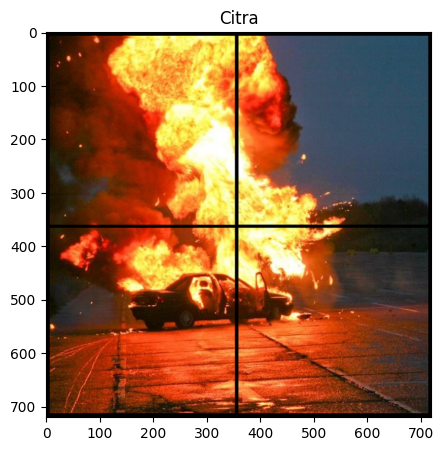

Tinggi gambar: 720
Lebar gambar: 720


In [237]:
mobilAsli = bacaRGB('Assets/Meledak.png')
mobilAbu = bacaAbu('Assets/Meledak.png')

tampilkan(mobilAsli)
tinggi, lebar = mobilAbu.shape
print("Tinggi gambar:", tinggi)
print("Lebar gambar:",lebar)

## Fungsi Slice

Function `slice()` digunakan untuk memotong citra secara horizontal maupun vertikal menggunakan teknik slicing array. Citra dibagi menjadi 4 bagian yaitu `Citra A`, `Citra B`, `Citra C`, dan `Citra D` dengan ukuran potongan yang disesuaikan berdasarkan tinggi dan lebar gambar, sekaligus digunakan untuk menghilangkan bagian garis hitam pada tepi citra

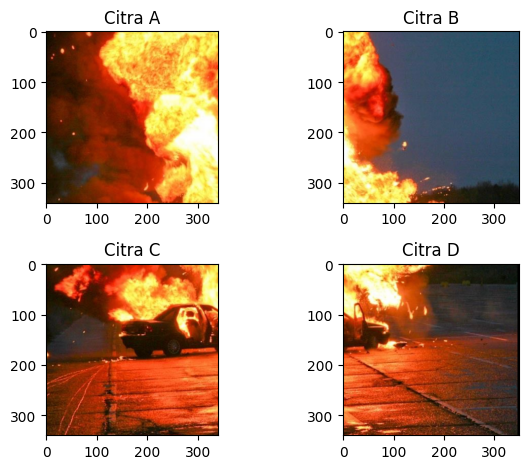

In [238]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

mobA = slice(mobilAsli, 10, 350, mode='H')
mobilA = slice(mobA, 10, 350, mode='V')
mobB = slice(mobilAsli, 10, 350, mode='H')
mobilB = slice(mobB, 360, 710, mode='V')
mobC = slice(mobilAsli, 370, 710, mode='H')
mobilC = slice(mobC, 10, 350, mode='V')
mobD = slice(mobilAsli, 370, 710, mode='H')
mobilD = slice(mobD, 370, 720, mode='V')

plt.subplot (2,2,1) 
plt.imshow(mobilA)
plt.title('Citra A')    

plt.subplot (2,2,2)
plt.imshow(mobilB)
plt.title('Citra B')

plt.subplot (2,2,3)
plt.imshow(mobilC)
plt.title('Citra C')

plt.subplot (2,2,4)
plt.imshow(mobilD)
plt.title('Citra D')

plt.tight_layout()


## Fungsi Merge

Function `merge()` digunakan untuk menggabungkan kembali potongan citra yang sebelumnya telah dilakukan slicing. Penggabungan dilakukan secara horizontal terlebih dahulu, kemudian hasil gabungan bagian atas dan bawah digabungkan kembali secara vertikal sehingga citra yang sudah tidak memiliki padding atau garis tepi hitam dapat disusun kembali menjadi satu gambar

In [239]:
def merge(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2  
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)   
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan 

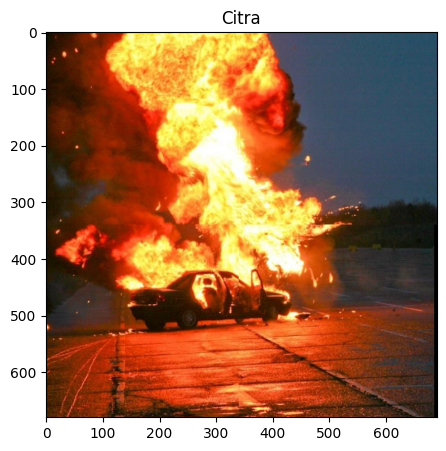

In [240]:
mergeAtas = merge(mobilA, mobilB, "H")
mergeBawah = merge(mobilC, mobilD, "H")
mergeAll = merge(mergeAtas, mergeBawah, "V")
tampilkan(mergeAll)

Pada tahap ini hasil penggabungan citra pada variabel `mergeAll` diubah menjadi grayscale menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_RGB2GRAY`. Function `bacaAbu()` tidak digunakan karena function tersebut membaca gambar langsung dari path file, sedangkan `mergeAll` merupakan variabel yang sudah menyimpan hasil penggabungan citra

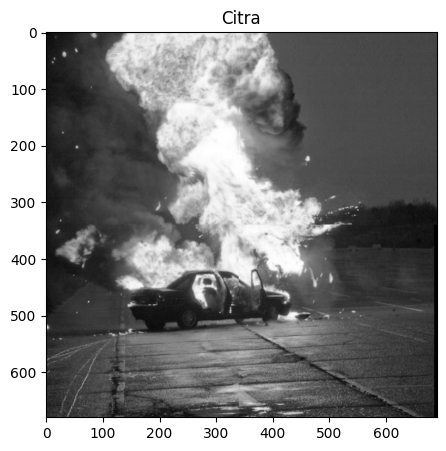

In [241]:
mobilGray = cv.cvtColor(mergeAll, cv.COLOR_RGB2GRAY)
tampilkan(mobilGray)

## Fungsi Histogram

Function `histogram()` digunakan untuk menghitung jumlah kemunculan setiap intensitas piksel pada citra grayscale. Histogram dibuat menggunakan array berukuran 256 yang merepresentasikan rentang intensitas piksel dari 0–255

Function `styleHisto()` digunakan untuk menampilkan histogram dengan tambahan pengaturan visual seperti judul, warna histogram, ukuran figure, label sumbu, dan batas intensitas piksel

Function `duaHisto()` digunakan untuk menampilkan dua histogram dalam satu figure secara berdampingan. Function ini digunakan untuk membandingkan histogram sebelum dan sesudah pengolahan citra

Function `gabungDuaHisto()` digunakan untuk menggabungkan dua histogram dalam satu grafik yang sama

In [242]:
def histogram(citra, normalisasi=False):
    citra = pastikan_uint8(citra)
    if len(citra.shape) != 2:
        raise ValueError("histogram hanya menerima citra grayscale 2D.")
    tinggi, lebar = citra.shape
    hist = np.zeros(256, dtype=float)
    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(citra[i, j])
            hist[nilai] += 1
    if normalisasi:
        total_piksel = tinggi * lebar
        hist = hist / total_piksel
    return hist

def styleHisto(hist, judul="Histogram", warna="red", figsize=(10, 4)):
    plt.figure(figsize=figsize)
    plt.bar(range(256), hist, color=warna, width=0.8)
    plt.title(judul)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel" if np.max(hist) > 1 else "Proporsi Piksel")
    plt.xlim([0, 255])
    plt.show()

def duaHisto(citra1, citra2, judul1="Sebelum", judul2="Sesudah"):
    hist1 = histogram(citra1)
    hist2 = histogram(citra2)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.bar(range(256), hist1, color="green", width=0.8)
    plt.title(judul1)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.subplot(1, 2, 2)
    plt.bar(range(256), hist2, color="red", width=0.8)
    plt.title(judul2)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])
    plt.tight_layout()
    plt.show()

def gabungDuaHisto(citra1, citra2, judul1="Sebelum", judul2="Sesudah"):
    hist1 = histogram(citra1)
    hist2 = histogram(citra2)

    plt.figure(figsize=(18, 10))
    plt.bar(range(256),hist1,color="green",alpha=0.6,width=0.8,label=judul1)
    plt.bar(range(256),hist2,color="red",alpha=0.6,width=0.8,label=judul2)

    plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])
    plt.legend()
    plt.show()


## Fungsi CDF dan Ekualisasi Histogram

Function `hitung_cdf()` digunakan untuk menghitung nilai Cumulative Distribution Function (CDF) dari histogram citra. Nilai CDF digunakan untuk mengetahui perhitungan distribusi intensitas piksel yang nantinya akan dipakai pada proses histogram equalization

Function `ekualisasi()` digunakan untuk melakukan histogram equalization pada citra grayscale. Proses ini dilakukan dengan mengubah nilai intensitas piksel berdasarkan hasil normalisasi CDF sehingga distribusi intensitas menjadi lebih merata dan kontras citra menjadi lebih jelas

In [243]:
def hitung_cdf(citra):
    hist = histogram(citra, normalisasi=False)
    cdf = np.zeros(256, dtype=float)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    return hist, cdf

def ekualisasi(citra):
    citra = pastikan_uint8(citra)
    if len(citra.shape) != 2:
        raise ValueError("ekualisasi hanya menerima citra grayscale 2D.")
    tinggi, lebar = citra.shape
    total_piksel = tinggi * lebar
    hist, cdf = hitung_cdf(citra)
    cdf_normal = np.round((cdf * 255) / total_piksel).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            nilai_lama = citra[i, j]
            hasil[i, j] = cdf_normal[nilai_lama]

    return hasil

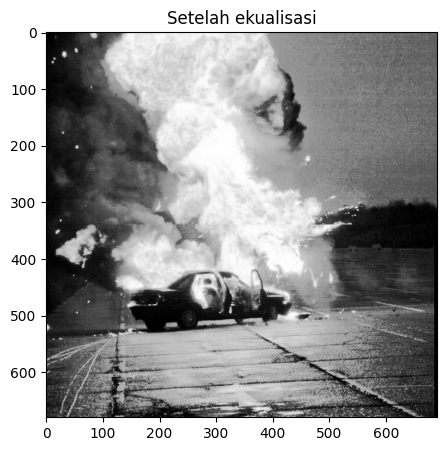

In [244]:
hasilEq = ekualisasi(mobilGray)
tampilkan(hasilEq, "Setelah ekualisasi")

Function `gabungDuaHisto()` dipanggil untuk menampilkan histogram sebelum dan sesudah proses histogram equalization. Berdasarkan grafik histogram terlihat bahwa distribusi piksel yang awalnya menumpuk pada beberapa intensitas tertentu menjadi lebih menyebar dan merata setelah dilakukan ekualisasi, sehingga kontras citra menjadi lebih jelas

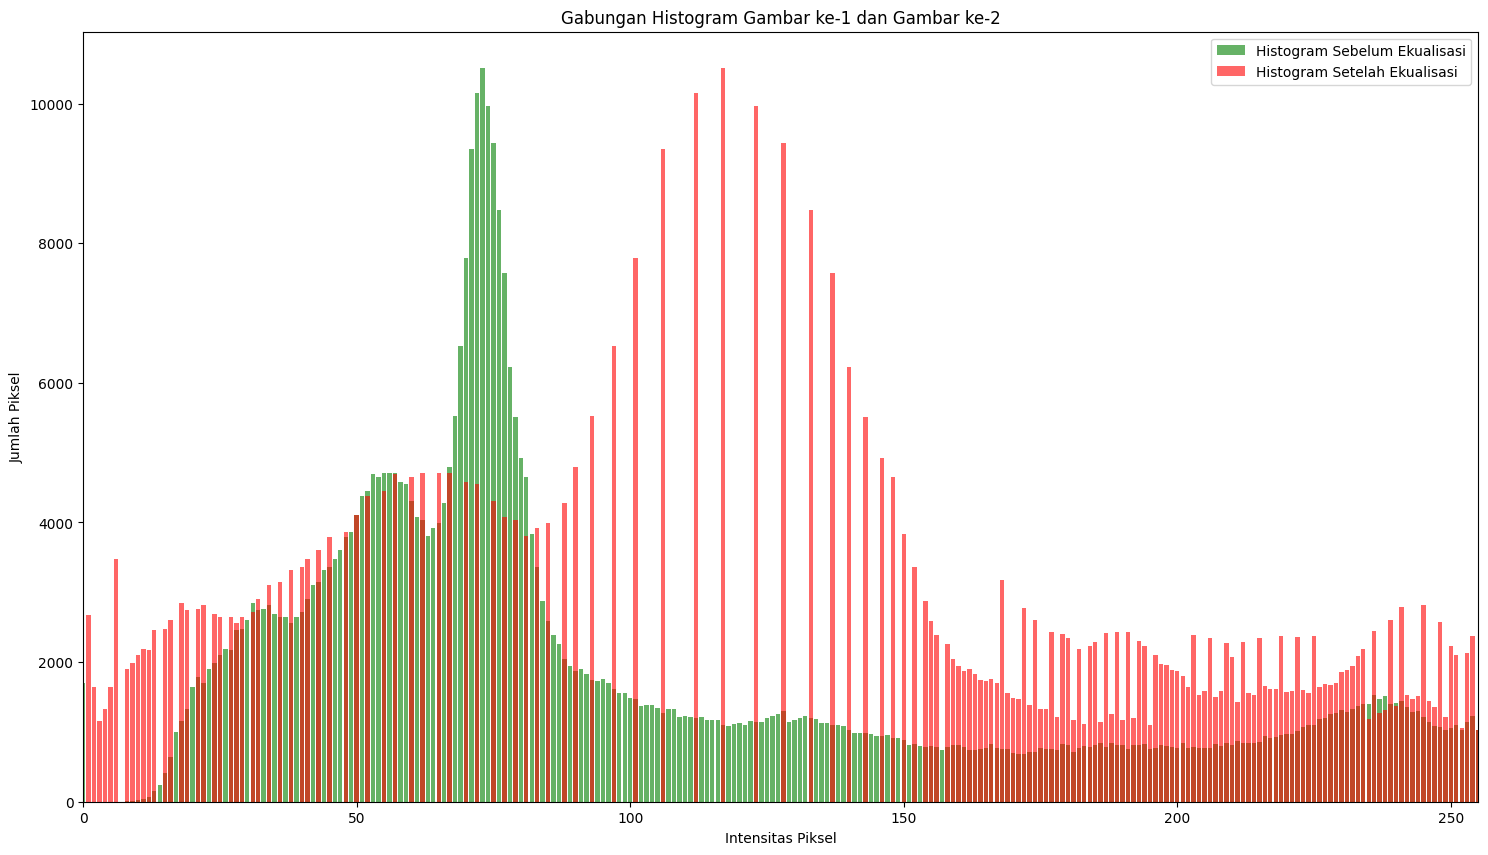

In [245]:
gabungDuaHisto(mobilGray, hasilEq, "Histogram Sebelum Ekualisasi", "Histogram Setelah Ekualisasi")

Pada tahap ini dilakukan pembacaan dua citra grayscale yaitu `Windut.png` dan `Bunga.png` menggunakan function `bacaAbu()`. Kedua citra kemudian ditampilkan secara bersamaan menggunakan `tampilkan_beberapa()` untuk mempermudah proses perbandingan citra

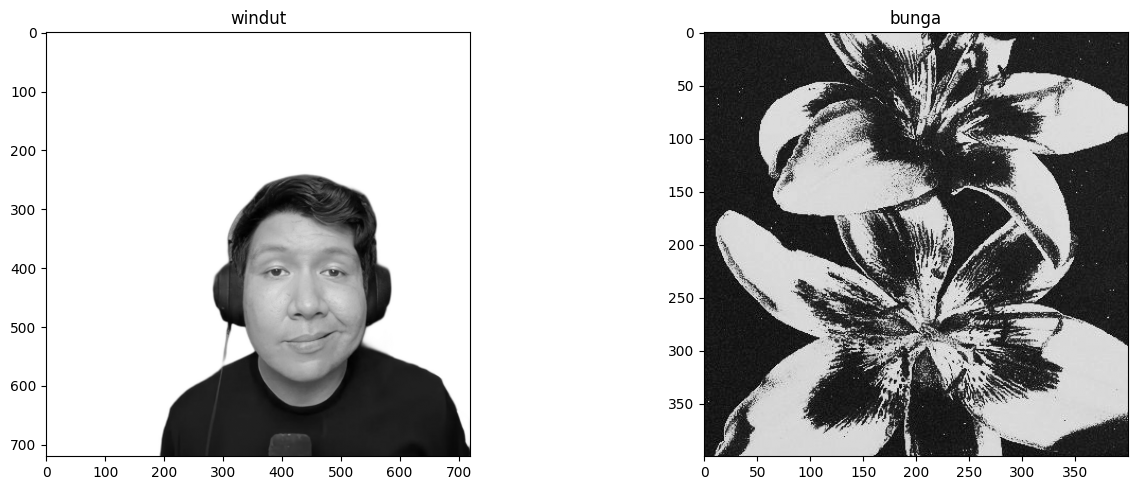

In [246]:
windut = bacaAbu('Assets/Windut.png')
bunga = bacaAbu('Assets/Bunga.png')

tampilkan_beberapa([windut, bunga], ["windut", "bunga"])

Setelah gambar diubah menjadi citra abu-abu, terlihat bahwa histogram pada gambar **Windut** memiliki penyebaran piksel yang sedikit dan menumpuk pada beberapa nilai intensitas saja. Hal ini menandakan bahwa gambar memiliki kontras yang rendah sehingga perbedaan terang dan gelapnya kurang terlihat jelas. Sedangkan pada gambar **Bunga Ireng**, penyebaran histogram lebih luas sehingga detail gambar dan perbedaan warnanya terlihat lebih jelas.

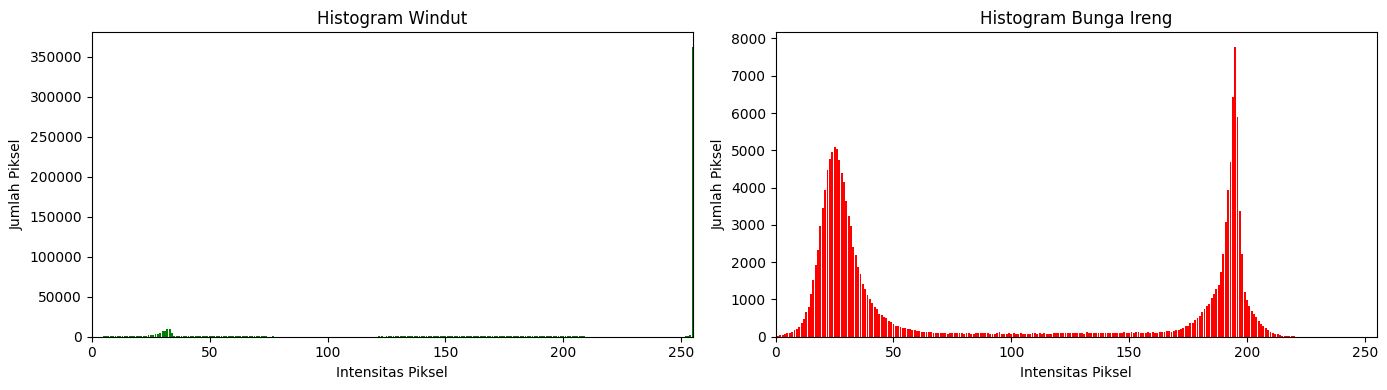

In [247]:
duaHisto(windut, bunga, "Histogram Windut", "Histogram Bunga Ireng")

## Fungsi Spesifikasi Histogram

Function `spesifikasi_histogram()` digunakan untuk melakukan spesifikasi histogram pada citra grayscale. Proses ini dilakukan dengan menyesuaikan distribusi intensitas piksel pada gambar asal agar menyerupai histogram dari gambar target.

Pada program ini, gambar **Windut** digunakan sebagai citra asal sedangkan gambar **Bunga Ireng** digunakan sebagai citra target karena memiliki penyebaran histogram yang lebih baik. Nantinya setiap nilai piksel pada gambar Windut akan dipetakan mengikuti distribusi histogram gambar Bunga Ireng sehingga kontras dan detail gambar menjadi jels.

In [248]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
    height_a, width_a = citra_asal.shape
    for i in range(height_a):
        for j in range(width_a):
            hist_asal[citra_asal[i, j]] += 1
    height_t, width_t = citra_target.shape
    for i in range(height_t):
        for j in range(width_t):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
 
    return hasil

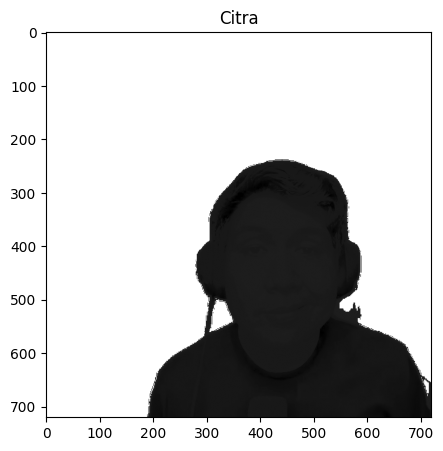

In [249]:
hasilSpes = spesifikasi_histogram(windut, bunga)
tampilkan(hasilSpes)

Histogram di bawah menunjukkan hasil setelah proses spesifikasi histogram dilakukan pada gambar **Windut** menggunakan histogram target dari gambar **Bunga Ireng**. Terlihat bahwa penyebaran intensitas piksel mengalami perubahan mengikuti distribusi histogram target sehingga kontras pada citra menjadi lebih jelas dibandingkan sebelumnya. Walaupun masih terdapat penumpukan piksel pada intensitas tertentu, hasil spesifikasi membuat distribusi intensitas menjadi lebih menyesuaikan dengan citra target.

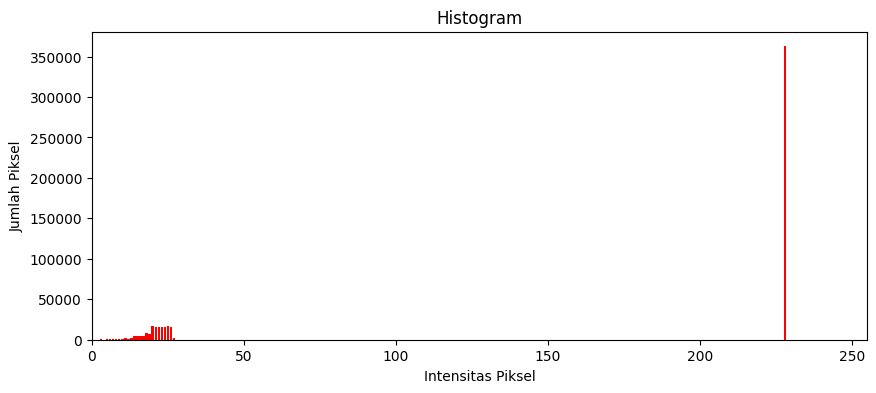

In [250]:
histoSpes = histogram(hasilSpes)
styleHisto(histoSpes)

## Fungsi Penggantian Latar dengan Threshold

Function `buat_mask_threshold()` digunakan untuk membuat mask berdasarkan nilai threshold pada citra grayscale. Jika mode menggunakan `lebih_besar`, maka piksel dengan intensitas lebih besar dari threshold akan bernilai `True`. Sedangkan jika menggunakan `lebih_kecil`, maka piksel dengan intensitas lebih kecil dari threshold akan dipilih.

Function `terapkan_mask()` digunakan untuk mengganti bagian tertentu pada citra asal menggunakan citra pengganti berdasarkan mask yang telah dibuat. Piksel yang memiliki nilai `True` pada mask akan diganti menggunakan piksel dari citra pengganti.

Function `ganti_latar_threshold()` digunakan untuk melakukan proses penggantian latar belakang citra menggunakan metode threshold. Sebelum proses dilakukan, ukuran kedua gambar disamakan terlebih dahulu dengan mengambil ukuran terkecil dari tinggi dan lebar gambar. Setelah itu dibuat mask berdasarkan threshold, lalu bagian gambar yang memenuhi kondisi threshold akan diganti menggunakan citra latar.

In [251]:
def buat_mask_threshold(citra, threshold=50, mode="lebih_besar"):
    citra = pastikan_uint8(citra)
    if mode == "lebih_besar":
        return citra > threshold
    if mode == "lebih_kecil":
        return citra < threshold

    raise ValueError("mode harus 'lebih_besar' atau 'lebih_kecil'.")

def terapkan_mask(citra_asal, citra_pengganti, mask):
    hasil = np.copy(citra_asal)
    hasil[mask] = citra_pengganti[mask]
    return hasil

def ganti_latar_threshold(citra_asal, citra_latar, threshold=50, mode="lebih_besar"):
    tinggi = min(citra_asal.shape[0], citra_latar.shape[0])
    lebar = min(citra_asal.shape[1], citra_latar.shape[1])

    citra_asal_crop = citra_asal[0:tinggi, 0:lebar]
    citra_latar_crop = citra_latar[0:tinggi, 0:lebar]

    mask = buat_mask_threshold(citra_asal_crop, threshold=threshold, mode=mode)
    hasil = terapkan_mask(citra_asal_crop, citra_latar_crop, mask)

    return hasil, mask

Pada proses ini, ukuran gambar `hasilSpes` dan `hasilEq` terlebih dahulu disamakan dengan mengambil tinggi dan lebar terkecil dari kedua citra. Setelah itu kedua gambar di-crop agar memiliki ukuran yang sama sehingga proses pengolahan dapat dilakukan tanpa error.

Selanjutnya dibuat mask menggunakan function `buat_mask_threshold()` dengan nilai threshold `200` dan mode `lebih_kecil`. Artinya, piksel pada gambar `hasilSpes_crop` yang memiliki intensitas kurang dari 200 akan dipilih pada mask.

Function `terapkan_mask()` kemudian digunakan untuk mengganti bagian tertentu pada gambar `hasilEq_crop` menggunakan piksel dari `hasilSpes_crop` sesuai area yang dipilih oleh mask. Hasil akhirnya disimpan pada variabel `hasil_akhir1` dan ditampilkan menggunakan function `tampilkan()`.

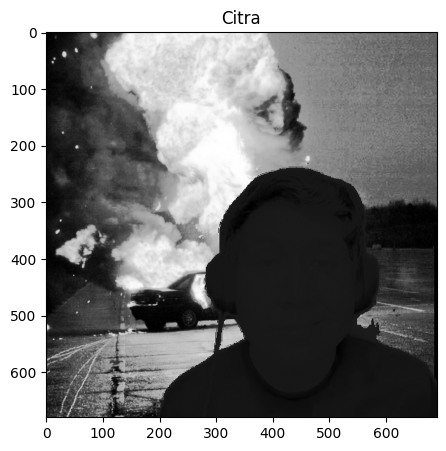

In [252]:
tinggi = min(hasilSpes.shape[0], hasilEq.shape[0])
lebar = min(hasilSpes.shape[1], hasilEq.shape[1])

hasilSpes_crop = hasilSpes[0:tinggi, 0:lebar]
hasilEq_crop = hasilEq[0:tinggi, 0:lebar]

mask = buat_mask_threshold(hasilSpes_crop,threshold=200,mode="lebih_kecil")
hasil_akhir1 = terapkan_mask(hasilEq_crop,hasilSpes_crop,mask)
tampilkan(hasil_akhir1)

Pada proses ini, gambar `windut` dan `hasilEq` terlebih dahulu disamakan ukurannya dengan melakukan crop sesuai tinggi dan lebar terkecil dari kedua citra. Setelah itu dibuat mask menggunakan threshold `250` dengan mode `lebih_kecil` untuk memilih bagian wajah dan objek utama pada gambar Windut. Selanjutnya function `terapkan_mask()` digunakan untuk mengambil bagian wajah dari gambar Windut dan menempatkannya pada gambar hasil equalization sehingga wajah Windut terlihat lebih jelas, sedangkan latar belakang yang awalnya putih berubah menjadi hasil histogram equalization.

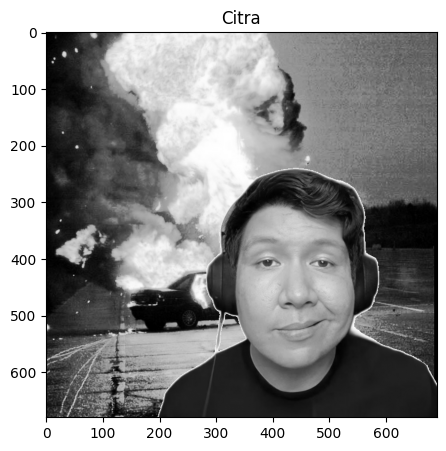

In [253]:
tinggi = min(windut.shape[0], hasilEq.shape[0])
lebar = min(windut.shape[1], hasilEq.shape[1])

windut_crop = windut[0:tinggi, 0:lebar]
hasilEq_crop = hasilEq[0:tinggi, 0:lebar]

mask = buat_mask_threshold(windut_crop, threshold=250, mode="lebih_kecil")
adaWindut= terapkan_mask(hasilEq_crop, windut_crop, mask)
tampilkan(adaWindut)

Pada proses ini dilakukan spesifikasi histogram pada gambar `adaWindut` menggunakan gambar `langit` sebagai citra target. Karena gambar langit memiliki dominasi warna terang seperti biru muda dan putih, maka distribusi intensitas pada histogram target lebih banyak berada pada nilai intensitas tinggi. Akibatnya, hasil spesifikasi membuat gambar menjadi cenderung lebih putih dan terang karena intensitas piksel pada gambar mengikuti karakteristik histogram dari gambar langit.

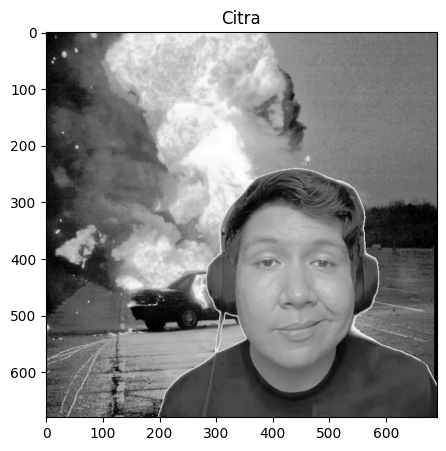

In [254]:
langit = bacaAbu('Assets/Langit.png')
hasilSpesWindut = spesifikasi_histogram(adaWindut, langit)
tampilkan(hasilSpesWindut)

Histogram di bawah menampilkan hasil spesifikasi histogram gambar Windut menggunakan citra target langit. Terlihat bahwa penyebaran intensitas piksel cenderung berada pada nilai intensitas tinggi dibandingkan sebelumnya karena histogram mengikuti karakteristik gambar langit yang didominasi warna terang seperti biru muda dan putih. Akibatnya, hasil gambar menjadi terlihat lebih terang dan cenderung lebih putih dibandingkan citra awal.

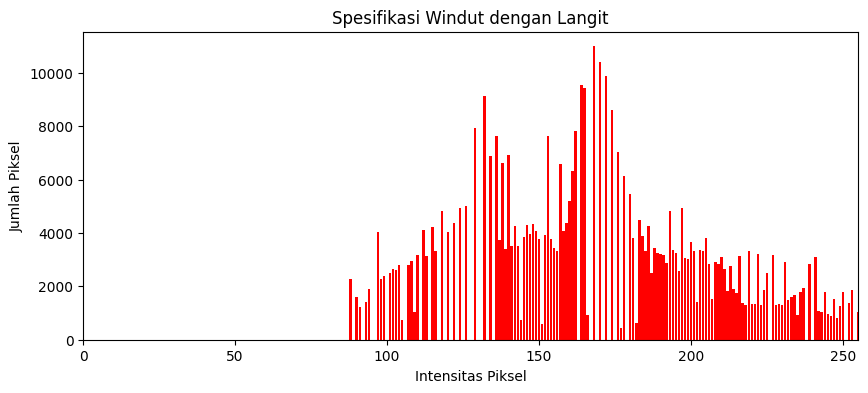

In [255]:
histoWindutAwan = histogram(hasilSpesWindut)
styleHisto(histoWindutAwan, "Spesifikasi Windut dengan Langit", "red")

## Proses Penggabungan Windut dengan Background Biru

Pada proses ini, gambar `windut` digabungkan dengan gambar background hasil `mergeAll`. Kedua gambar terlebih dahulu disamakan ukurannya dengan melakukan crop berdasarkan tinggi dan lebar terkecil. Setelah itu gambar Windut diubah menjadi grayscale untuk membantu proses pemisahan objek dan latar belakang. Program kemudian melakukan pengecekan setiap piksel, dimana piksel dengan intensitas grayscale lebih dari `240` dianggap sebagai latar belakang putih sehingga diganti menggunakan piksel dari gambar background. Sedangkan bagian selain latar belakang tetap menggunakan gambar Windut, namun warna RGB dimodifikasi dengan mengurangi intensitas merah dan hijau serta meningkatkan intensitas biru sehingga menghasilkan efek warna yang lebih menarik pada gambar akhir `Windut Cipularang`.

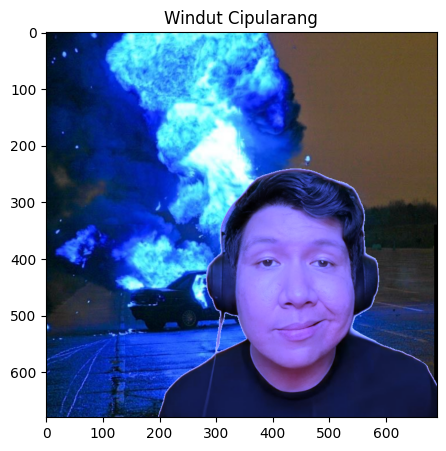

In [256]:
windut = bacaRGB('Assets/Windut.png')
background = cv.cvtColor(mergeAll, cv.COLOR_RGB2BGR)

tinggi = min(windut.shape[0], background.shape[0])
lebar = min(windut.shape[1], background.shape[1])

windut_crop = windut[0:tinggi, 0:lebar]
background_crop = background[0:tinggi, 0:lebar]

gray = np.round(
    0.299 * windut_crop[:, :, 0] +
    0.587 * windut_crop[:, :, 1] +
    0.114 * windut_crop[:, :, 2]
).astype(np.uint8)

hasil = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        if gray[i, j] > 240:
            hasil[i, j] = background_crop[i, j]

        else:

            r = windut_crop[i, j, 0]
            g = windut_crop[i, j, 1]
            b = windut_crop[i, j, 2]

            r = np.clip(r * 0.7, 0, 255)
            g = np.clip(g * 0.8, 0, 255)
            b = np.clip(b * 1.8, 0, 255)

            hasil[i, j] = [r, g, b]

tampilkan(hasil, "Windut Cipularang")